# Argus — Dataset Creation (Flat, per-frame)

This notebook builds the **flat, per-frame** dataset used to train the non-recurrent models:
the RandomForest (`04_random_forest_training.ipynb`) and the Dense feedforward NN
(`05_dense_nn_training.ipynb`). It also underlies the face-crop CNN path indirectly, in that it
shares the same raw videos, sampling rate, and label mapping as
`06_dataset_creation_face_crops.ipynb`.

Unlike [`01_dataset_creation_lstm.ipynb`](./01_dataset_creation_lstm.ipynb), there is **no
sliding-window step here**: every valid sampled frame becomes its own row, mapped to a single
drowsiness label — the label of the clip it came from. This is deliberately simpler and much
cheaper to generate (no per-window duplication of overlapping frames across 6 window durations),
which is the whole point of having this notebook: generating the LSTM's windowed dataset is
comparatively expensive, and most model families here don't need sequences at all.

The MediaPipe setup, `GeometricRatioFeatureLayer`, and per-frame feature extraction pipeline in
this notebook are copied from `01_dataset_creation_lstm.ipynb` and must stay in sync with it (and
with `03_deployment_export.ipynb` and `src/cv-argus/src/model/layers.py`) — see the note above
the layer definition below.


## Project Overview

**Project:** System for detecting drowsiness in truck drivers and providing preventive assistance.

**Objective:** Define a reproducible pipeline that converts raw `.mp4` recordings into a
structured `.csv` dataset, used to train the Argus `LSTM` (recurrent neural network) to predict
a driver's drowsiness level.

**Solution:** After evaluating several architectures, we chose an `LSTM` because it is
lightweight, easy to implement, and fits our pipeline well: a pretrained `CNN-based` model
(`MediaPipe FaceLandmarker`) extracts facial landmarks, blendshape scores, and head pose per
frame; these are preprocessed into a set of interpretable ratios and scores (see below), which
become the time-series input to the `LSTM` that predicts the drowsiness level.



## Drowsiness levels (labels)



**Argus classifies 3 states, not 6** — `Alert`, `Low Vigilant`, `Drowsy` — aligned to the same
tri-partition [UTA-RLDD](https://sites.google.com/view/utarldd/home) (Ghoddoosian, Galib &
Athitsos, 2019) uses over the Karolinska Sleepiness Scale (KSS), so that dataset's labels can be
adopted directly instead of re-mapped through a second, harder-to-justify scheme:

| Class | KSS basis (per UTA-RLDD) | Numeric label (this project) |
|---|---|---|
| Alert | KSS 1–3: "completely conscious... could easily drive for long hours" | 1 |
| Low Vigilant | KSS 6–7: subtle sleepiness signs present, or present but no effort needed to stay alert; driving discouraged | 2 |
| Drowsy | KSS 8–9: actively fighting to not fall asleep | 3 |

(KSS 4–5 is deliberately excluded by UTA-RLDD as an ambiguous middle zone — we follow the same
convention rather than inventing our own boundary there.)

**Argus's own footage was originally recorded on a finer 1–6 scale** (see the git history of
this cell for that table) before this project adopted UTA-RLDD's 3-class scheme. Those clips
keep their original `level_<1-6>_clip_<N>.mp4` filenames — nothing gets renamed — and are
mapped down at metadata-generation time (see "Video Processing Loop" below):

| Original level | → | Class |
|---|---|---|
| 1 (alert, fully awake), 2 (alert, slightly relaxed) | → | Alert (1) |
| 3 (mild signs of tiredness), 4 (tired) | → | Low Vigilant (2) |
| 5 (very tired/sleepy), 6 (entering microsleep) | → | Drowsy (3) |


### Data Collection Methodology

Two sources feed this dataset, combined into one `metadata.csv`:

**Argus's own footage** (6 subjects as of this writing) — levels 1–5 (pre-mapping) were
self-recorded under genuine fatigue conditions (late at night, after sleep deprivation, real
tiredness, not staged); level 6 ("entering microsleep") was acted, but performed while already
at a genuine level-5 state rather than acted from a fully alert baseline. Worth naming plainly:
the original level 6 (now folded into `Drowsy`) has weaker ground-truth confidence than the
self-recorded levels — standard practice in this field (most public drowsiness datasets include
some acted extreme-drowsiness footage for the same safety/practicality reason), but not
something to leave implicit in the report.

**[UTA-RLDD](https://sites.google.com/view/utarldd/home)** (Ghoddoosian, Galib & Athitsos,
CVPRW 2019) — 60 participants, 180 videos (~10 minutes each, ~30 hours total), each video
self-recorded by the participant at home or at university specifically *while* in one of the
three KSS-derived states above. Like Argus's own data, this is naturalistic self-recorded
fatigue, not a lab-controlled elicitation protocol — a good methodological fit, not just a
convenient source of volume. Added primarily to fix two problems the original 6-subject dataset
had: too few subjects for the model to learn anything beyond memorizing those specific people,
and — more specifically — some classes existing in only one subject's footage, making a
leakage-free train/test split with full class coverage on both sides mathematically impossible
(see the "Ingesting UTA-RLDD" section below for how source videos become usable clips here, and
`docs/` for the fuller writeup of that diagnosis).

Because each UTA-RLDD video carries one constant label for its entire ~10 minutes (participants
recorded themselves *during* that state, not through a session that drifted between states),
extracting multiple shorter sub-clips from one source video and giving every sub-clip that
video's label is valid — unlike a dataset where drowsiness varies within a single session.


## Feature extraction from facial landmarks



We use MediaPipe's pretrained `FaceLandmarker` model, which internally runs a face detector,
a face mesh model, and a blendshape prediction model to output, per frame:

- 478 3D facial landmarks (x, y, z)
- 52 ARKit-style blendshape scores (0–1), pre-normalized for pose and scale
- A 4×4 head-pose transformation matrix

Rather than feeding raw landmark coordinates directly into the LSTM (noisy, pose- and
scale-dependent, and very high-dimensional), we derive a curated set of interpretable features
from these outputs:



1. **Manual EAR / MAR** (`output_face_landmarks`): Eye Aspect Ratio and Mouth Aspect Ratio,
   computed directly from the 2D landmark coordinates using the standard six-point (eyes) and
   four-point (mouth) formulas. We keep these even though blendshapes cover similar ground,
   because they are simple, fully interpretable, and give us an independent baseline to compare
   against the blendshape-based features during the statistical validation step.
2. **Face blendshapes** (`output_face_blendshapes=True`): 52 ARKit-style coefficients
   (`eyeBlinkLeft`, `eyeBlinkRight`, `eyeSquintLeft/Right`, `jawOpen`, `browDownLeft/Right`,
   `mouthClose`, etc.), already normalized by MediaPipe's model for head pose and face scale —
   effectively pre-computed facial action units, and generally less noisy than EAR/MAR when the
   driver's head is turned.
3. **Head pose** (`output_facial_transformation_matrixes=True`): a 4×4 transformation matrix
   from which we extract pitch, yaw, and roll directly. Head nodding is a strong signal of
   microsleep, and is not captured by the blendshapes above.

### Candidate per-frame features


The table below lists every per-frame feature we currently extract as a candidate for the LSTM
input sequence, along with the rationale for including it.

| Category | Feature(s) | Source | Rationale |
|---|---|---|---|
| Eyes (manual EAR) | `EAR_left`, `EAR_right` | 2D landmarks, computed manually | Kept for interpretability and as a comparison baseline, even though it is pose-sensitive |
| Eyes (blendshape) | `eyeBlinkLeft`, `eyeBlinkRight` | Blendshape | Pose-robust equivalent of the same phenomenon captured by EAR |
| Eyes (blendshape) | `eyeSquintLeft`, `eyeSquintRight` | Blendshape | Squinting associated with visual fatigue |
| Eyes (blendshape) | `eyeWideLeft`, `eyeWideRight` | Blendshape | Widening of the eyes as a conscious effort to stay awake (sometimes precedes a lapse) |
| Gaze | `eyeLookDownLeft`, `eyeLookDownRight` | Blendshape | Gaze drifting downward together with the head |
| Mouth (manual MAR) | `MAR` | 2D landmarks, computed manually | Kept for interpretability, same rationale as EAR |
| Mouth / jaw (blendshape) | `jawOpen`, `mouthFunnel`, `mouthStretchLeft`, `mouthStretchRight` | Blendshape | Yawning — **note the speech/singing confound**, see below |
| Mouth (blendshape) | `mouthClose`, `mouthPressLeft`, `mouthPressRight` | Blendshape | Loss of muscle tone around the mouth at rest |
| Eyebrows (blendshape) | `browDownLeft`, `browDownRight`, `browInnerUp` | Blendshape | Conscious effort to stay alert |
| Speech confound flag | `mouthSmileLeft`, `mouthSmileRight`, short-window mouth variance | Blendshape | Auxiliary signal to help detect whether the driver is talking or singing, so it is not mistaken for yawning — relevant since truck drivers frequently talk on the radio/phone or sing |
| Head pose | `pitch`, `yaw`, `roll` | Facial transformation matrix (not a blendshape) | Head nodding is a strong signal of microsleep |
| Sample quality | `detection_confidence`, `frame_has_face` (0/1) | Detector metadata | Used to discard or down-weight low-confidence frames |



### How we will validate which features actually matter




Rather than assuming all of the above are equally useful, we will validate each feature's
relevance statistically once the aggregated per-clip dataset is built (see the next section):

1. **Shapiro-Wilk test** on each aggregated feature, to check for normality and decide between
   parametric and non-parametric tests.
2. **Kruskal-Wallis test** comparing each feature's distribution across drowsiness levels
   (non-parametric, since the data is expected to be non-normal) — a low p-value indicates the
   feature meaningfully discriminates between levels.
3. **Spearman correlation** between each feature and the drowsiness level, since the label is
   ordinal rather than continuous-linear.
4. **Linear mixed-effects model**, with drowsiness level as a fixed effect and subject as a
   random effect, to control for repeated measurements from the same person.
5. **Pairwise Spearman correlation matrix between features**, to detect redundancy (e.g. if
   `EAR_left` and `eyeBlinkLeft` are highly correlated, only one may be needed in the final
   input set).

Features that show no significant relationship with drowsiness level in this analysis are
candidates for removal before finalizing the LSTM input set.

### Why one CSV, one row per frame

There's no binary-artifact strategy to explain here the way there is for the windowed dataset:
each valid frame's 58 features (7 geometric ratios + 51 blendshapes) plus its subject/level are
written directly as one row of `frame_features.csv` under `dataset_processed/`. No padding, no
window durations, no per-clip files — a `pandas.DataFrame.to_csv` at the end of the extraction
loop. This is intentionally the simplest possible artifact format, since the whole reason this
notebook exists is to avoid the generation cost of the windowed scheme for models that don't need
sequences.

The tradeoff, made explicit for the titulación report: a single frame is a much weaker drowsiness
signal than a multi-second window, since duration/velocity-of-eye-closure (what actually
distinguishes a long blink from a normal one) is invisible in one frame. That's exactly why the
LSTM notebook still keeps its windowed dataset — this flat dataset is for models
(RandomForest, Dense NN, the face-crop CNN) that are structurally incapable of seeing a sequence
anyway, so training them on windows would only add cost without adding signal they can use.


# Project Structure & Feature Extraction Strategy


We reuse the same raw video source and sampling convention as the windowed dataset:

* **Sampling Rate:** Videos are processed at **10 FPS** (`sampling_fps = 10`), identical to `01_dataset_creation_lstm.ipynb`.
* **No windowing:** Every sampled frame is evaluated on its own. Frames where the face was lost (`ear_mar_valid == 0`) are dropped, same validity rule as the windowed notebook, but per-frame instead of discarding an entire window.
* **Label:** Each surviving frame inherits the single 3-class drowsiness label of the clip it came from (`map_level`, identical mapping to the windowed notebook).
* **Output Artifact:** One consolidated `frame_features.csv` under `dataset_processed/`.


```Text
/content/drive/MyDrive/Argus/
├── models/                    <- Stores our pretrained MediaPipe task & trained model weights
├── dataset/
│   └── raw_videos/            <- Same raw clips used by 01_dataset_creation_lstm.ipynb
│       └── subject_01/ ...
└── dataset_processed/
    ├── lstm_windows.csv       <- Written by 01_dataset_creation_lstm.ipynb (windowed, padded)
    └── frame_features.csv     <- Written by this notebook (one row per valid frame)
```


## Google Drive Connection

We mount Google Drive to seamlessly save and load our project files (pretrained models, raw video datasets, and processed artifacts) directly in the cloud, ensuring that all our work persists safely across Google Colab session disconnects.

In [1]:
from google.colab import drive
import os

# Mount Google Drive in the Colab environment
drive.mount('/content/drive')

# Define the base root path for the Argus project
project_folder = "/content/drive/MyDrive/Argus"

print(f"Google Drive successfully mounted! Base project directory: {project_folder}")

Mounted at /content/drive
Google Drive successfully mounted! Base project directory: /content/drive/MyDrive/Argus


## Project Directory Setup & Validation
Firstly, validate and initialize the project root folder.

In [2]:
import os

if not os.path.exists(project_folder):
    raise Exception(f"The target directory could not be initialized: '{project_folder}'.")

Then, validate and create the necessary project folders to ensure they exist.


In [3]:
import os

# Define the subpaths for the Argus project structure
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
raw_videos_folder = f"{dataset_folder}/raw_videos"
processed_folder = f"{dataset_folder}/dataset_processed"

if not os.path.exists(raw_videos_folder):
  raise Exception(f"The target directory could not be initialized: '{raw_videos_folder}'.")

folders_to_create = [
    models_folder,
    processed_folder,
]

for folder in folders_to_create:
    os.makedirs(folder, exist_ok=True)

print("Project folder structure successfully created and verified.")


Project folder structure successfully created and verified.


Finally, check for uploaded subject directories. If no subjects exist, issue a warning to ensure data is present before proceeding.


In [4]:
import glob

# Validation check: Ensure raw_videos folder contains video clips
# Search recursively for any .mp4 files within the subject folders
video_files = glob.glob(os.path.join(raw_videos_folder, "**/*.mp4"), recursive=True)
if len(video_files) == 0:
    raise Exception(f"No video clips found in the specified directory: '{raw_videos_folder}'.")
print(f"[SUCCESS] Raw video directory validated: Found {len(video_files)} clip(s) ready for processing.")

[SUCCESS] Raw video directory validated: Found 189 clip(s) ready for processing.


### Exploratory visualization

Skipped here — these raw clips are the same ones already visualized (clip counts/durations by
level and by subject) in `01_dataset_creation_lstm.ipynb`. Refer to that notebook's histograms;
nothing about class/subject balance changes by switching to a flat, per-frame dataset.


#  Media Pipe Model Setup & Feature Engineering & Dataset Assembly Pipeline Orchestration


## Dataset Assembly Pipeline Orchestration

This section turns raw `.mp4` clips into structured artifacts for LSTM training.

### The Processing Logic:
1. **Feature Extraction:** MediaPipe extracts landmarks and blendshapes at 10 FPS.
2. **Stream Generation:** The pipeline slices the continuous data into overlapping "streams" (1s–6s windows).
3. **Quality Gate:** The script checks index 6 (`ear_mar_valid`) of every frame in a window. If any frame is marked as invalid (face lost), the entire window is dropped.
4. **Indexing:** Metadata is generated to map every individual `.npy` stream back to its original clip and subject.

## Model Media Pipe Setup & Installing Dependencies



Before any feature extraction can run, a pretrained MediaPipe FaceLandmarker model bundle must exist inside models_folder. This section is idempotent and safe to re-run: it checks for an existing model first, and only downloads one if missing — so once it has run once for a given Google Drive, later runs (or other notebooks sharing the same Argus/models/ folder) reuse the cached file instead of re-downloading.

### Downloading and Setting Up the MediaPipe Model Bundle
1. Install Dependencies: Run the installation command to ensure `mediapipe` and `opencv-python` are available in your environment.

2. Define Directory & Path: Set your target directory (`models_folder`) and verify or create it.

3. Download and Move Model: Check if the pretrained `MediaPipe` `FaceLandmarker` model bundle exists, download it if missing, and move/save it into `models_folder`.


In [5]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [6]:
# Verify that the model exist
!ls -l {models_folder}

total 655504
-rw------- 1 root root    240091 Aug 19 00:39 best_dense_nn.keras
-rw------- 1 root root    924868 Aug 18 01:46 best_lstm_model.keras
-rw------- 1 root root    229746 Aug 18 22:21 blaze_face_short_range.tflite
-rw------- 1 root root      2007 Aug 19 00:29 dense_feature_scaler_20260819_0029.joblib
-rw------- 1 root root      2007 Aug 19 00:38 dense_feature_scaler_20260819_0038.joblib
-rw------- 1 root root    240091 Aug 19 00:31 dense_nn_20260819_0029.keras
-rw------- 1 root root    240091 Aug 19 00:41 dense_nn_20260819_0038.keras
-rw------- 1 root root   3758596 Aug 17 04:05 face_landmarker.task
-rw------- 1 root root      1103 Aug 17 00:49 feature_scaler_20260817_0034.joblib
-rw------- 1 root root      1103 Aug 17 20:13 feature_scaler_20260817_1856.joblib
-rw------- 1 root root   1783216 Aug 17 01:32 lstm_drowsiness_20260817_0101.keras
-rw------- 1 root root    924868 Aug 18 02:23 lstm_drowsiness_20260817_1856.keras
-rw------- 1 root root   5292089 Aug 17 00:49 rf_classif

In [7]:
import urllib.request

media_pipe_url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task"
media_pipe_filename = "face_landmarker.task"
media_pipe_path = os.path.join(models_folder, media_pipe_filename)

# Download the model only if it doesn't already exist and catch any errors
if not os.path.exists(media_pipe_path):
    print(f"Downloading MediaPipe Face Landmarker model to {media_pipe_path}...")
    try:
        urllib.request.urlretrieve(media_pipe_url, media_pipe_path)
        print("Download complete.")
    except Exception as e:
        raise RuntimeError(f"Failed to download the MediaPipe model from {media_pipe_url}. Error: {e}")
else:
    print(f"Model already exists at {media_pipe_path}. Skipping download.")

Model already exists at /content/drive/MyDrive/Argus/models/face_landmarker.task. Skipping download.


### # MediaPipe Face Landmarker Quantization -- (Still Working on it)



This subsection implements the workflow for the **Argus** drowsiness detection project, focusing on downloading, extracting, and optimizing the MediaPipe Face Landmarker model for deployment.

1. Installing the AI quantizer library

In [ ]:
# !pip install -q ai-edge-quantizer

2. Extract the `.task` bundle (it is a ZIP archive)

In [ ]:
# import shutil
# import zipfile

# extract_dir = "extracted_task"
# if os.path.exists(extract_dir):
#     shutil.rmtree(extract_dir)   # clean up previous extraction

# with zipfile.ZipFile(media_pipe_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# print(f"Extracted contents to {extract_dir}/")
# !ls -lh {extract_dir}

3. Locate all TFLite models inside the extracted folder

In [ ]:
# # Build the full paths
# model_paths = {
#     "face_detector": os.path.join(extract_dir, "face_detector.tflite"),
#     "face_landmarks": os.path.join(extract_dir, "face_landmarks_detector.tflite"),
#     "face_blendshapes": os.path.join(extract_dir, "face_blendshapes.tflite"),
# }

# # Validate all exist before starting
# missing = [name for name, path in model_paths.items() if not os.path.exists(path)]
# if missing:
#     raise FileNotFoundError(
#         f"The following required TFLite models are missing from '{extract_dir}': {', '.join(missing)}"
#     )

4. Quantize the TFLite modeles using `ai_edge_quantizer` and replace them.

In [ ]:
# from ai_edge_quantizer import quantizer, recipe
# import shutil
# import os

# # Using the dynamic_wi8_afp32 recipe to achieve INT8 quantization.
# # This reduces weight precision to 8-bit integers while maintaining activations in float32,
# # which is the targeted optimization for the Argus project deployment.
# for name, path in model_paths.items():
#     print(f"Quantizing {name} to INT8 (Dynamic)...")
#     qt = quantizer.Quantizer(path)

#     # Load the dynamic INT8 quantization recipe
#     qt.load_quantization_recipe(recipe.dynamic_wi8_afp32())

#     # Define the temporary output path for the INT8 model
#     quantized_temp = f"{name}_dynamic_int8.tflite"
#     if os.path.exists(quantized_temp):
#         os.remove(quantized_temp)

#     # Execute the quantization and export
#     qt.quantize().export_model(quantized_temp)

#     # Replace the original file in the extracted folder with the INT8 version
#     shutil.move(quantized_temp, path)
#     print(f"  Successfully replaced {path} with dynamic INT8 version.")

6. Repackage the folder into a new `.task` file (ZIP with no compression)

In [ ]:
# new_task_path = os.path.join(models_folder, "face_landmarker_quantized.task")
# if os.path.exists(new_task_path):
#     os.remove(new_task_path)

# with zipfile.ZipFile(new_task_path, 'w', zipfile.ZIP_STORED) as zipf:
#     for root, dirs, files in os.walk(extract_dir):
#         for file in files:
#             full_path = os.path.join(root, file)
#             arcname = os.path.relpath(full_path, extract_dir)
#             zipf.write(full_path, arcname)

# print(f"✅ Quantized .task file created: {new_task_path}")
# print(f"   Size: {os.path.getsize(new_task_path):,} bytes")

7. Quick validation – load the quantized model with MediaPipe

In [ ]:
# from mediapipe.tasks import python
# from mediapipe.tasks.python import vision

# base_options = python.BaseOptions(model_asset_path=new_task_path)
# options = vision.FaceLandmarkerOptions(
#     base_options=base_options,
#     running_mode=vision.RunningMode.IMAGE,
#     num_faces=1,
#     min_face_detection_confidence=0.5
# )
# detector = vision.FaceLandmarker.create_from_options(options)

# print("✅ Quantized model loaded successfully!")

### Test MediaPipe Face Landmarker on a Random Frame

First, let's import the necessary libraries and set up the `FaceLandmarker` for image mode, as we'll be processing a single static image.

In [8]:
import random
import cv2
import os
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# Fix: Explicitly define base_options using the path resolved in the download step
base_options = mp_python.BaseOptions(model_asset_path=os.path.abspath(media_pipe_path))

# Creating new options for IMAGE running mode
image_landmarker_options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
)

# Create the FaceLandmarker detector instance
detector = vision.FaceLandmarker.create_from_options(image_landmarker_options)

print("✅ MediaPipe FaceLandmarker detector initialized for IMAGE mode.")

✅ MediaPipe FaceLandmarker detector initialized for IMAGE mode.


Next, we'll randomly select one of your video files and then pick a random frame from it. This frame will be used to test the Face Landmarker.

Selected video for test: /content/drive/MyDrive/Argus/dataset/raw_videos/subject_24/level_2_clip_01.mp4
Selected random frame index: 9


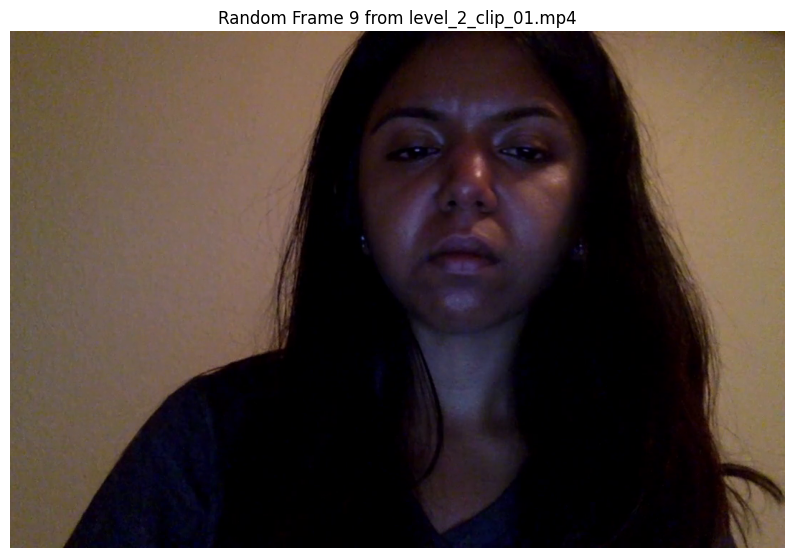

✅ Random frame selected and displayed.


In [9]:
# Randomly select a video file
selected_video_path = random.choice(video_files)
print(f"Selected video for test: {selected_video_path}")

# Open the video file
cap = cv2.VideoCapture(selected_video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video file: {selected_video_path}")

# Get total frame count
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if frame_count == 0:
    raise ValueError(f"Video file {selected_video_path} has no frames.")

# Select a random frame index
random_frame_idx = random.randint(0, frame_count - 1)
print(f"Selected random frame index: {random_frame_idx}")

# Set the video capture to the random frame
cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)

# Read the frame
ret, bgr_frame = cap.read()
cap.release()

if not ret:
    raise Exception(f"Failed to read frame {random_frame_idx} from {selected_video_path}")

# Display the raw selected frame
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title(f"Random Frame {random_frame_idx} from {os.path.basename(selected_video_path)}")
plt.axis('off')
plt.show()

print("✅ Random frame selected and displayed.")

Now we'll run the `FaceLandmarker` detector on the selected frame. The `detector` will identify faces and extract facial landmarks, blendshapes, and the head pose transformation matrix.

In [10]:
# Convert the OpenCV BGR frame to RGB and then to a MediaPipe Image object
rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

# Perform face landmark detection
detection_result = detector.detect(mp_image)

if detection_result.face_landmarks:
    print(f"✅ Face(s) detected: {len(detection_result.face_landmarks)}")
    # The first face's blendshapes can be accessed via: detection_result.face_blendshapes[0]
    # And transformation matrix via: detection_result.facial_transformation_matrixes[0]
else:
    print("⚠️ No face detected in the selected frame.")

✅ Face(s) detected: 1


Finally, let's visualize the detected landmarks on the original frame. We'll use MediaPipe's drawing utilities for this.

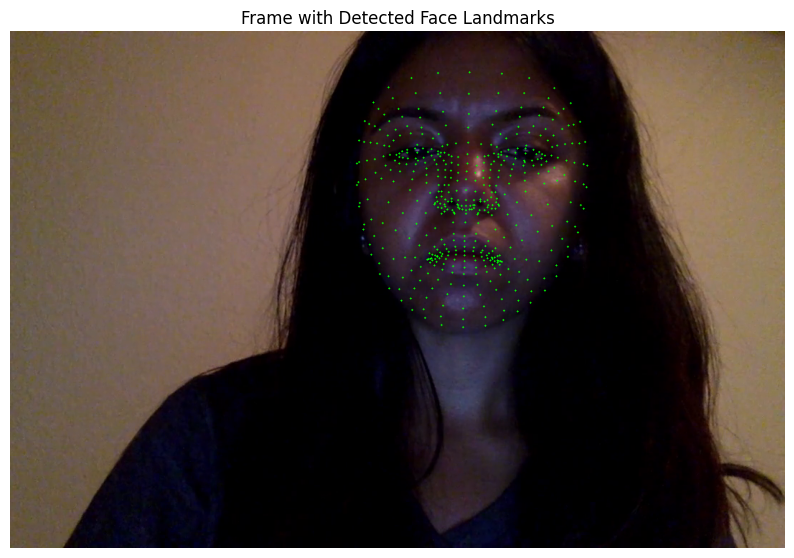

✅ Annotated frame displayed.


In [11]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks.python import vision

# Use the existing detector (from your previous cells)
# detector is already created

# Convert frame and detect (assuming detection_result is already available)
# If not, run detection again:
# rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
# mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
# detection_result = detector.detect(mp_image)

# Make a copy of the frame to annotate
annotated_frame = bgr_frame.copy()
height, width, _ = annotated_frame.shape

if detection_result.face_landmarks:
    # Get the first face's landmarks
    landmarks = detection_result.face_landmarks[0]  # list of NormalizedLandmark

    # Draw each landmark as a small circle
    for lm in landmarks:
        x = int(lm.x * width)
        y = int(lm.y * height)
        cv2.circle(annotated_frame, (x, y), 1, (0, 255, 0), -1)   # green dots

    # Optionally, draw connections (tesselation) – you can import the connection list
    # from the old API without needing the full solutions module:
    try:
        from mediapipe.solutions.face_mesh_connections import FACEMESH_TESSELATION
    except ImportError:
        # Fallback: define a minimal set of connections (or skip)
        FACEMESH_TESSELATION = []

    # Draw connections as lines (if available)
    for connection in FACEMESH_TESSELATION:
        idx1, idx2 = connection
        # Ensure indices are valid
        if idx1 < len(landmarks) and idx2 < len(landmarks):
            x1 = int(landmarks[idx1].x * width)
            y1 = int(landmarks[idx1].y * height)
            x2 = int(landmarks[idx2].x * width)
            y2 = int(landmarks[idx2].y * height)
            cv2.line(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 1)

    # Display the annotated frame
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.title("Frame with Detected Face Landmarks")
    plt.axis('off')
    plt.show()
    print("✅ Annotated frame displayed.")
else:
    print("No face landmarks to draw.")

## Feature Extraction per frame

1. FaceLandmaker initialization & Landmark Index Constnats
2. Geometric Ratio Tensor Layer For Functions (EAR, MAR, Head Pose)

### 1. FaceLandmarker Initialization & Landmark Index Constants



To ensure temporal consistency and avoid state-tracking errors across different video files, we configure the `FaceLandmarker` options to use `VIDEO` running mode. While the configuration is defined globally in `face_landmarker_options`, the **FeatureExtractionPipeline** now instantiates a fresh detector for every video processed. This resets the internal MediaPipe timestamp clock, preventing errors related to non-monotonic timestamps when moving from the end of one clip to the start of another.

Key configuration highlights:

*   **Blendshapes & Transformation Matrix:** Both are enabled to extract 52 facial action units and head pose (pitch/yaw/roll) simultaneously.
*   **Landmark Indices:** `left_eye_ear_idx`, `right_eye_ear_idx`, and `mouth_mar_idx` use standard MediaPipe FaceMesh topology (6-point eyes, 4-point mouth) which remains stable across all subjects.
*   **Sampling Strategy:** `sampling_fps` (defaulting to 10) ensures the training data matches the temporal distribution achievable on the target Raspberry Pi 5 hardware.

This setup reuses the `media_pipe_path` resolved in the previous download step.

In [12]:
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# --- FaceLandmarker configuration (media_pipe_path already resolved by the download step) ---
base_options = mp_python.BaseOptions(model_asset_path=os.path.abspath(media_pipe_path))
face_landmarker_options = vision.FaceLandmarkerOptions(
    base_options = base_options,
    running_mode = vision.RunningMode.VIDEO,
    num_faces = 1,
    min_face_detection_confidence = 0.5,
    min_face_presence_confidence = 0.5,
    min_tracking_confidence = 0.5,
    output_face_blendshapes = True,
    output_facial_transformation_matrixes = True,
)

print("FaceLandmarker configuration and constants ready.")

FaceLandmarker configuration and constants ready.


### 2. Geometric Ratio Tensor Layer For Functions (EAR, MAR, Head Pose)

Here we define the TensorFlow layer that we will use both during dataset building (for consistency) and later when we assemble the LSTM model.

The geometric helper functions needed for computing (`EAR`, `MAR`, `Head Pose`)

To enable export to a single `.tflite` file — and to keep feature extraction identical between dataset creation and inference — we now implement an exact TensorFlow‑native counterpart: **`GeometricRatioFeatureLayer`**. This layer performs the same geometric calculations using `tf` operations.

In [13]:
import tensorflow as tf
import numpy as np

@tf.keras.utils.register_keras_serializable(package="Argus")
class GeometricRatioFeatureLayer(tf.keras.layers.Layer):
    """
    TensorFlow-native counterpart to compute_ear, compute_mar, and rotation_matrix_to_euler.
    Inputs:
        landmarks_xy : (batch, 478, 2)   -- normalized (x, y) coordinates
        rotation_matrix : (batch, 3, 3)  -- top‑left 3×3 block of the facial transformation matrix
    Returns:
        (batch, 7) : [EAR_left, EAR_right, MAR, pitch, yaw, roll, ear_mar_valid]
    """
    def __init__(self, pose_validity_threshold_deg=20.0, **kwargs):
        super().__init__(**kwargs)
        self.pose_validity_threshold_deg = pose_validity_threshold_deg
        self.left_eye_idx  = tf.constant([33, 160, 158, 133, 153, 144], dtype=tf.int32)
        self.right_eye_idx = tf.constant([362, 385, 387, 263, 373, 380], dtype=tf.int32)
        self.mouth_idx     = tf.constant([61, 291, 13, 14], dtype=tf.int32)
        self.blendshape_names = [
            "browDownLeft", "browDownRight", "browInnerUp", "browOuterUpLeft", "browOuterUpRight",
            "cheekPuff", "cheekSquintLeft", "cheekSquintRight", "eyeBlinkLeft", "eyeBlinkRight",
            "eyeLookDownLeft", "eyeLookDownRight", "eyeLookInLeft", "eyeLookInRight",
            "eyeLookOutLeft", "eyeLookOutRight", "eyeLookUpLeft", "eyeLookUpRight",
            "eyeSquintLeft", "eyeSquintRight", "eyeWideLeft", "eyeWideRight",
            "jawForward", "jawLeft", "jawOpen", "jawRight", "mouthClose", "mouthDimpleLeft",
            "mouthDimpleRight", "mouthFrownLeft", "mouthFrownRight", "mouthFunnel",
            "mouthLeft", "mouthLowerDownLeft", "mouthLowerDownRight", "mouthPressLeft",
            "mouthPressRight", "mouthPucker", "mouthRight", "mouthRollLower",
            "mouthRollUpper", "mouthShrugLower", "mouthShrugUpper", "mouthSmileLeft",
            "mouthSmileRight", "mouthStretchLeft", "mouthStretchRight", "mouthUpperUpLeft",
            "mouthUpperUpRight", "noseSneerLeft", "noseSneerRight"
        ]

    def get_config(self):
        config = super().get_config()
        config.update({"pose_validity_threshold_deg": self.pose_validity_threshold_deg})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    @staticmethod
    def _dist(points, i, j):
        a = points[..., i, :]
        b = points[..., j, :]
        return tf.norm(a - b, axis=-1)

    def _ear(self, landmarks, idx):
        p = tf.gather(landmarks, idx, axis=-2)
        vertical = self._dist(p, 1, 5) + self._dist(p, 2, 4)
        horizontal = 2.0 * self._dist(p, 0, 3)
        return tf.math.divide_no_nan(vertical, horizontal)

    def _mar(self, landmarks, idx):
        p = tf.gather(landmarks, idx, axis=-2)
        vertical = self._dist(p, 2, 3)
        horizontal = self._dist(p, 0, 1)
        return tf.math.divide_no_nan(vertical, horizontal)

    @staticmethod
    def _rotation_matrix_to_euler(R):
        r00, r10, r20 = R[..., 0, 0], R[..., 1, 0], R[..., 2, 0]
        r21, r22 = R[..., 2, 1], R[..., 2, 2]
        r11, r12 = R[..., 1, 1], R[..., 1, 2]
        sy = tf.sqrt(r00**2 + r10**2)
        singular = sy < 1e-6
        pitch = tf.where(singular, tf.atan2(-r12, r11), tf.atan2(r21, r22))
        yaw = tf.atan2(-r20, sy)
        roll = tf.where(singular, tf.zeros_like(r10), tf.atan2(r10, r00))
        return pitch * (180.0 / np.pi), yaw * (180.0 / np.pi), roll * (180.0 / np.pi)

    def call(self, landmarks_xy, rotation_matrix):
        ear_left = self._ear(landmarks_xy, self.left_eye_idx)
        ear_right = self._ear(landmarks_xy, self.right_eye_idx)
        mar = self._mar(landmarks_xy, self.mouth_idx)
        pitch, yaw, roll = self._rotation_matrix_to_euler(rotation_matrix)
        ear_mar_valid = tf.cast(tf.logical_and(tf.abs(yaw) < self.pose_validity_threshold_deg, tf.abs(pitch) < self.pose_validity_threshold_deg), tf.float32)
        return tf.stack([ear_left, ear_right, mar, pitch, yaw, roll, ear_mar_valid], axis=-1)

> **Sync warning:** `GeometricRatioFeatureLayer` above is copied verbatim from
> `01_dataset_creation_lstm.ipynb` and must be kept byte-identical to it, to
> `03_deployment_export.ipynb`, and to `src/cv-argus/src/model/layers.py` — Keras needs the exact
> same class definition to deserialize any saved model that embeds it. There is no automated
> check that all four stay in sync; verify manually after editing any one of them.


## Pipeline Orchestration: Connecting MediaPipe, Ratio Layer, and Video Processing

### 1. Pipeline Configuration Constants


This subsection defines the global parameters that govern per-frame feature extraction and the 3-class label mapping. No window sizes or stride are needed here — every valid frame becomes its own row.


In [14]:
# --- Pipeline Configuration Constants ---
# Must match 01_dataset_creation_lstm.ipynb's sampling_fps, pose_validity_threshold_deg, and
# label-mapping constants exactly, so both datasets describe the same frames the same way.
sampling_fps = 10                     # Target extraction rate (frames per second)
pose_validity_threshold_deg = 20.0    # Pitch/Yaw range for valid EAR/MAR

# --- Raw level (1-6, from filenames) -> 3-class drowsiness label mapping ---
# Identical to 01_dataset_creation_lstm.ipynb -- see that notebook's Pipeline Configuration
# Constants cell for the full rationale (Argus's own subject_01..subject_06 clips use the
# original 6-level scale and get mapped down; UTA-RLDD-derived subject_07+ clips are already
# 3-class and pass through unchanged).
EXTERNAL_SUBJECT_START = 7
RAW_LEVEL_TO_CLASS = {1: 1, 2: 1, 3: 2, 4: 2, 5: 3, 6: 3}  # 1=Alert, 2=Low Vigilant, 3=Drowsy

def map_level(subject_dir_name: str, raw_level: int) -> int:
    subject_num = int(subject_dir_name.split("_")[-1])
    if subject_num >= EXTERNAL_SUBJECT_START:
        if raw_level not in (1, 2, 3):
            raise ValueError(f"External subject '{subject_dir_name}' has out-of-range level {raw_level}")
        return raw_level
    return RAW_LEVEL_TO_CLASS[raw_level]

# --- Fixed landmark index sets for EAR/MAR ---
left_eye_ear_idx  = [33, 160, 158, 133, 153, 144]
right_eye_ear_idx = [362, 385, 387, 263, 373, 380]
mouth_mar_idx     = [61, 291, 13, 14]

print(f"✅ Pipeline constants initialized. Sampling: {sampling_fps} FPS")


✅ Pipeline constants initialized. Sampling: 10 FPS


### 2. Pipeline Orchestration Definition

Now we define the core orchestration logic that processes a raw video and produces the feature matrix.

**Components:**
- **MediaPipe detector** – extracts landmarks, blendshapes, and the 3×3 rotation matrix per frame.
- **`GeometricRatioFeatureLayer`** – computes EAR, MAR, and head‑pose angles (pitch, yaw, roll) from the raw landmarks and rotation matrix.
- **Video reader** – uses OpenCV to sample frames at the target `sampling_fps`.

The pipeline returns a NumPy array of shape `(num_frames, 59)` where each row consists of:
- 7 base features: `[EAR_left, EAR_right, MAR, pitch, yaw, roll, ear_mar_valid]`
- 52 blendshape scores (MediaPipe’s ARKit‑style coefficients)

In [15]:
import cv2
import numpy as np
import tensorflow as tf
from mediapipe.tasks.python import vision
import mediapipe as mp
from tqdm.auto import tqdm
import os

class FeatureExtractionPipeline:
    def __init__(self, face_landmarker_options: vision.FaceLandmarkerOptions,
                 ratio_layer: tf.keras.layers.Layer,
                 sampling_fps: int = 10):
        self.face_landmarker_options = face_landmarker_options
        self.ratio_layer = ratio_layer
        self.sampling_fps = sampling_fps

    def process_video(self, video_path: str):
        # Create a fresh detector per video to avoid timestamp issues
        detector_local = vision.FaceLandmarker.create_from_options(self.face_landmarker_options)
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            detector_local.close()
            raise IOError(f"Cannot open video: {video_path}")

        src_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_stride = max(1, round(src_fps / self.sampling_fps))

        rows = []
        dropped_frames = 0
        frame_idx = 0

        pbar = tqdm(total=total_frames, desc=f"Processing {os.path.basename(video_path)[:20]}...", leave=False)

        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break

            if frame_idx % frame_stride == 0:
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
                timestamp_ms = int(frame_idx * (1000.0 / src_fps))

                result = detector_local.detect_for_video(mp_image, timestamp_ms)

                if result.face_landmarks:
                    lm = result.face_landmarks[0]
                    landmarks_xy = tf.constant([[p.x, p.y] for p in lm], dtype=tf.float32)
                    R = np.array(result.facial_transformation_matrixes[0])[:3, :3] if result.facial_transformation_matrixes else np.eye(3, dtype=np.float32)
                    R_tf = tf.constant(R, dtype=tf.float32)

                    # Compute EAR, MAR, Pose using the TF layer
                    ratios = self.ratio_layer(landmarks_xy[tf.newaxis, ...], R_tf[tf.newaxis, ...]).numpy()[0]

                    # Extract 52 blendshapes
                    bs_dict = {b.category_name: b.score for b in result.face_blendshapes[0]} if result.face_blendshapes else {}
                    bs_scores = [bs_dict.get(name, 0.0) for name in self.ratio_layer.blendshape_names]

                    row = np.concatenate([ratios, bs_scores]).astype(np.float32)
                    rows.append(row)
                else:
                    dropped_frames += 1
                    # Append a dummy row where validity (index 6) is 0.0
                    # The label mapping happens in the loop cell based on the filename.
                    num_features = 7 + len(self.ratio_layer.blendshape_names)
                    dummy = np.zeros(num_features, dtype=np.float32)
                    rows.append(dummy)

            frame_idx += 1
            pbar.update(1)

        pbar.close()
        cap.release()
        detector_local.close()

        return (np.array(rows, dtype=np.float32), dropped_frames) if rows else (None, 0)

### 3. Pipeline Orchestration Run & Dataset Creation


This section processes each raw video clip once, keeps every valid frame (dropping only
frames where the face was lost), and writes them straight to `frame_features.csv`. There is no
per-window duplication, so this pass touches each frame exactly once instead of once per
overlapping window.


### Initial Setup and Blendshape Names


In [16]:
# --- Ensure required variables are defined ---
frame_features_csv_path = os.path.join(processed_folder, "frame_features.csv")

# --- Ensure the ratio layer has the blendshape names (if not already defined) ---
if not hasattr(GeometricRatioFeatureLayer, 'blendshape_names'):
    GeometricRatioFeatureLayer.blendshape_names = [
        "browDownLeft", "browDownRight", "browInnerUp", "browOuterUpLeft", "browOuterUpRight",
        "cheekPuff", "cheekSquintLeft", "cheekSquintRight",
        "eyeBlinkLeft", "eyeBlinkRight",
        "eyeLookDownLeft", "eyeLookDownRight", "eyeLookInLeft", "eyeLookInRight",
        "eyeLookOutLeft", "eyeLookOutRight", "eyeLookUpLeft", "eyeLookUpRight",
        "eyeSquintLeft", "eyeSquintRight", "eyeWideLeft", "eyeWideRight",
        "jawForward", "jawLeft", "jawOpen", "jawRight",
        "mouthClose", "mouthDimpleLeft", "mouthDimpleRight", "mouthFrownLeft", "mouthFrownRight",
        "mouthFunnel", "mouthLeft", "mouthLowerDownLeft", "mouthLowerDownRight",
        "mouthPressLeft", "mouthPressRight", "mouthPucker", "mouthRight",
        "mouthRollLower", "mouthRollUpper", "mouthShrugLower", "mouthShrugUpper",
        "mouthSmileLeft", "mouthSmileRight", "mouthStretchLeft", "mouthStretchRight",
        "mouthUpperUpLeft", "mouthUpperUpRight", "noseSneerLeft", "noseSneerRight",
    ]

# Column order for the flat CSV: 7 geometric ratios + blendshapes, named for readability
# (the windowed CSV instead names columns by flattened (timestep, feature) index, since it
# has no natural per-feature names once flattened -- here we can afford proper names).
GEOMETRIC_FEATURE_NAMES = ["EAR_left", "EAR_right", "MAR", "pitch", "yaw", "roll", "ear_mar_valid"]
FEATURE_COLUMN_NAMES = GEOMETRIC_FEATURE_NAMES + GeometricRatioFeatureLayer.blendshape_names
num_features = len(FEATURE_COLUMN_NAMES)
print(f"num_features = {num_features}")


num_features = 58


### Instantiate Components and Dataset Reset Option

Same as the windowed notebook: a `reset_dataset` flag controls whether `frame_features.csv` is
rebuilt from scratch.


In [17]:
# --- Instantiate components ---
ratio_layer = GeometricRatioFeatureLayer(pose_validity_threshold_deg=pose_validity_threshold_deg)
pipeline = FeatureExtractionPipeline(face_landmarker_options, ratio_layer, sampling_fps=sampling_fps)


In [24]:
import os

# --- Safety flag: set to True to delete existing dataset and rebuild from scratch ---
reset_dataset = False  # Change to True when you want to rebuild

if reset_dataset:
    if os.path.exists(frame_features_csv_path):
        os.remove(frame_features_csv_path)
        print(f"🧹 Existing flat dataset removed: {frame_features_csv_path}")
    print("✨ Ready for fresh extraction.")


### Video Processing Loop

For each video: extract the subject/raw level from its path, map it to the final 3-class label,
run `pipeline.process_video` to get the full per-clip feature array, then keep every row where
`ear_mar_valid == 1` (drop the rest) and tag each surviving row with `(subject, level,
parent_video, frame_idx)`. No windowing, no padding.


In [ ]:
import re
import numpy as np
import os
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_single_video_flat(video_path, pipeline_instance, external_subject_start, raw_level_to_class):
    """Helper function to process a single video for parallel execution.

    Returns a list of per-frame row-dicts (metadata + one column per named feature), one per
    valid (face-detected) frame in the clip.
    """
    filename = os.path.basename(video_path)
    subject = os.path.basename(os.path.dirname(video_path))

    level_match = re.search(r'level_(\d+)', filename, re.IGNORECASE)
    if not level_match:
        return None, (filename, "Missing 'level_' prefix")

    raw_level = int(level_match.group(1))
    subject_num = int(subject.split("_")[-1])
    if subject_num >= external_subject_start:
        if raw_level not in (1, 2, 3):
            return None, (filename, f"External subject with out-of-range level {raw_level}")
        level = raw_level
    else:
        level = raw_level_to_class[raw_level]

    result = pipeline_instance.process_video(video_path)
    if result is None or result[0] is None:
        return None, (filename, "Face detection failure")

    full_features, drop_count = result[0], result[1]
    local_rows = []
    for frame_idx, feat_row in enumerate(full_features):
        if feat_row[6] == 0.0:  # ear_mar_valid
            continue
        row = {
            "subject": subject,
            "level": level,
            "parent_video": filename,
            "frame_idx": frame_idx,
        }
        row.update({name: float(val) for name, val in zip(FEATURE_COLUMN_NAMES, feat_row)})
        local_rows.append(row)

    return local_rows, None

if reset_dataset:
    rows = []
    skipped = []
    max_workers = os.cpu_count() or 2

    print(f"🚀 Starting parallel extraction with {max_workers} workers...")

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(process_single_video_flat, vp, pipeline, EXTERNAL_SUBJECT_START, RAW_LEVEL_TO_CLASS)
            for vp in video_files
        ]
        main_pbar = tqdm(as_completed(futures), total=len(video_files), desc="Parallel Progress")
        for future in main_pbar:
            local_rows, error = future.result()
            if error:
                skipped.append(error)
            if local_rows:
                rows.extend(local_rows)

    print(f"\nParallel Extraction Finished. Generated {len(rows)} frame rows.")
    if skipped:
        print(f"Skipped {len(skipped)} files.")
else:
    print("\nreset_dataset is False. Skipping parallel processing.")


🚀 Starting parallel extraction with 2 workers...


Parallel Progress:   0%|          | 0/189 [00:00<?, ?it/s]


Parallel Extraction Finished. Generated 173730 frame rows.


### Writing the Flat CSV and Cleanup


In [25]:
import pandas as pd

if reset_dataset:
    df_frame_features = pd.DataFrame(rows)
    df_frame_features.to_csv(frame_features_csv_path, index=False)

    print(f"\n✅ Dataset built: {len(rows)} frame rows written to {frame_features_csv_path}")
    print(f"   CSV shape: {df_frame_features.shape}")
    if skipped:
        print(f"⚠️  Skipped {len(skipped)} clips:")
        for name, reason in skipped:
            print(f"   - {name}: {reason}")

detector.close()


### Dataset Sanity Check


In [26]:
import pandas as pd

df_frame_features = pd.read_csv(frame_features_csv_path)
level_counts = df_frame_features['level'].value_counts().sort_index()

print("--- Dataset Sanity Check ---")
print(f"Total frame rows: {len(df_frame_features)}")
print(f"Distinct clips: {df_frame_features['parent_video'].nunique()}")
print(f"Distinct subjects: {df_frame_features['subject'].nunique()}")
print("\nFrame counts per level:")
for lvl, count in level_counts.items():
    print(f"  Level {lvl}: {count} frames")

missing_levels = [l for l in [1, 2, 3] if l not in level_counts.index]
if not missing_levels:
    print("\n✅ Success: All 3 levels are present in the dataset.")
else:
    print(f"\n⚠️ Warning: Missing levels {missing_levels} in the processed data.")

display(df_frame_features.head())


--- Dataset Sanity Check ---
Total frame rows: 173730
Distinct clips: 13
Distinct subjects: 24

Frame counts per level:
  Level 1: 62095 frames
  Level 2: 55486 frames
  Level 3: 56149 frames

✅ Success: All 3 levels are present in the dataset.


,subject,level,parent_video,frame_idx,EAR_left,EAR_right,MAR,pitch,yaw,roll,...,mouthShrugLower,mouthShrugUpper,mouthSmileLeft,mouthSmileRight,mouthStretchLeft,mouthStretchRight,mouthUpperUpLeft,mouthUpperUpRight,noseSneerLeft,noseSneerRight
0,subject_01,2,level_3_clip_01.mp4,0,0.114950,0.108054,0.002580,3.087128,2.920601,0.402353,...,0.001831,0.011256,0.017331,0.013834,0.019482,0.070397,0.001138,0.001605,0.000004,7.531470e-07
1,subject_01,2,level_3_clip_01.mp4,1,0.112726,0.114522,0.002889,3.025081,2.706256,0.437057,...,0.004653,0.019070,0.015049,0.010519,0.019271,0.062360,0.002191,0.002477,0.000004,7.624668e-07
2,subject_01,2,level_3_clip_01.mp4,2,0.117107,0.115228,0.002639,2.952981,2.275612,-0.058283,...,0.006084,0.026091,0.013265,0.008458,0.020688,0.062509,0.003175,0.003320,0.000005,6.939328e-07
3,subject_01,2,level_3_clip_01.mp4,3,0.114554,0.110693,0.004694,3.001753,1.654256,-0.034143,...,0.004784,0.022034,0.006556,0.004436,0.011137,0.036149,0.001913,0.001953,0.000005,6.883258e-07
4,subject_01,2,level_3_clip_01.mp4,4,0.116685,0.112452,0.003603,3.094782,1.336988,0.089875,...,0.004535,0.020189,0.007107,0.004722,0.018811,0.040179,0.001412,0.001620,0.000005,7.333782e-07


# Statistical Validation & Feature Correlation


Now that we have the flat, per-frame dataset, we verify that the features we extracted (EAR,
MAR, blendshapes, and pose) actually correlate with the drowsiness class (Alert / Low Vigilant /
Drowsy). This is the same validation `02_model_training.ipynb` used to run on window-mean-
aggregated features; it now runs directly on `frame_features.csv`, since each row already *is*
one frame's features — no aggregation step needed. `04_random_forest_training.ipynb` and
`05_dense_nn_training.ipynb` both read this section's conclusions when selecting features.


In [27]:
import pandas as pd

df_frame_features = pd.read_csv(frame_features_csv_path)

# Convenience column matching the naming used throughout the rest of the project.
df_frame_features['EAR_mean'] = (df_frame_features['EAR_left'] + df_frame_features['EAR_right']) / 2

print(f"Loaded {len(df_frame_features)} frame rows, {df_frame_features['subject'].nunique()} subjects.")
display(df_frame_features.head())


Loaded 173730 frame rows, 24 subjects.


,subject,level,parent_video,frame_idx,EAR_left,EAR_right,MAR,pitch,yaw,roll,...,mouthShrugUpper,mouthSmileLeft,mouthSmileRight,mouthStretchLeft,mouthStretchRight,mouthUpperUpLeft,mouthUpperUpRight,noseSneerLeft,noseSneerRight,EAR_mean
0,subject_01,2,level_3_clip_01.mp4,0,0.114950,0.108054,0.002580,3.087128,2.920601,0.402353,...,0.011256,0.017331,0.013834,0.019482,0.070397,0.001138,0.001605,0.000004,7.531470e-07,0.111502
1,subject_01,2,level_3_clip_01.mp4,1,0.112726,0.114522,0.002889,3.025081,2.706256,0.437057,...,0.019070,0.015049,0.010519,0.019271,0.062360,0.002191,0.002477,0.000004,7.624668e-07,0.113624
2,subject_01,2,level_3_clip_01.mp4,2,0.117107,0.115228,0.002639,2.952981,2.275612,-0.058283,...,0.026091,0.013265,0.008458,0.020688,0.062509,0.003175,0.003320,0.000005,6.939328e-07,0.116167
3,subject_01,2,level_3_clip_01.mp4,3,0.114554,0.110693,0.004694,3.001753,1.654256,-0.034143,...,0.022034,0.006556,0.004436,0.011137,0.036149,0.001913,0.001953,0.000005,6.883258e-07,0.112623
4,subject_01,2,level_3_clip_01.mp4,4,0.116685,0.112452,0.003603,3.094782,1.336988,0.089875,...,0.020189,0.007107,0.004722,0.018811,0.040179,0.001412,0.001620,0.000005,7.333782e-07,0.114569


### Spearman Correlation Heatmap


Since our drowsiness classes (Alert < Low Vigilant < Drowsy) are **ordinal**, we use Spearman correlation to see which features increase or decrease monotonically with sleepiness.


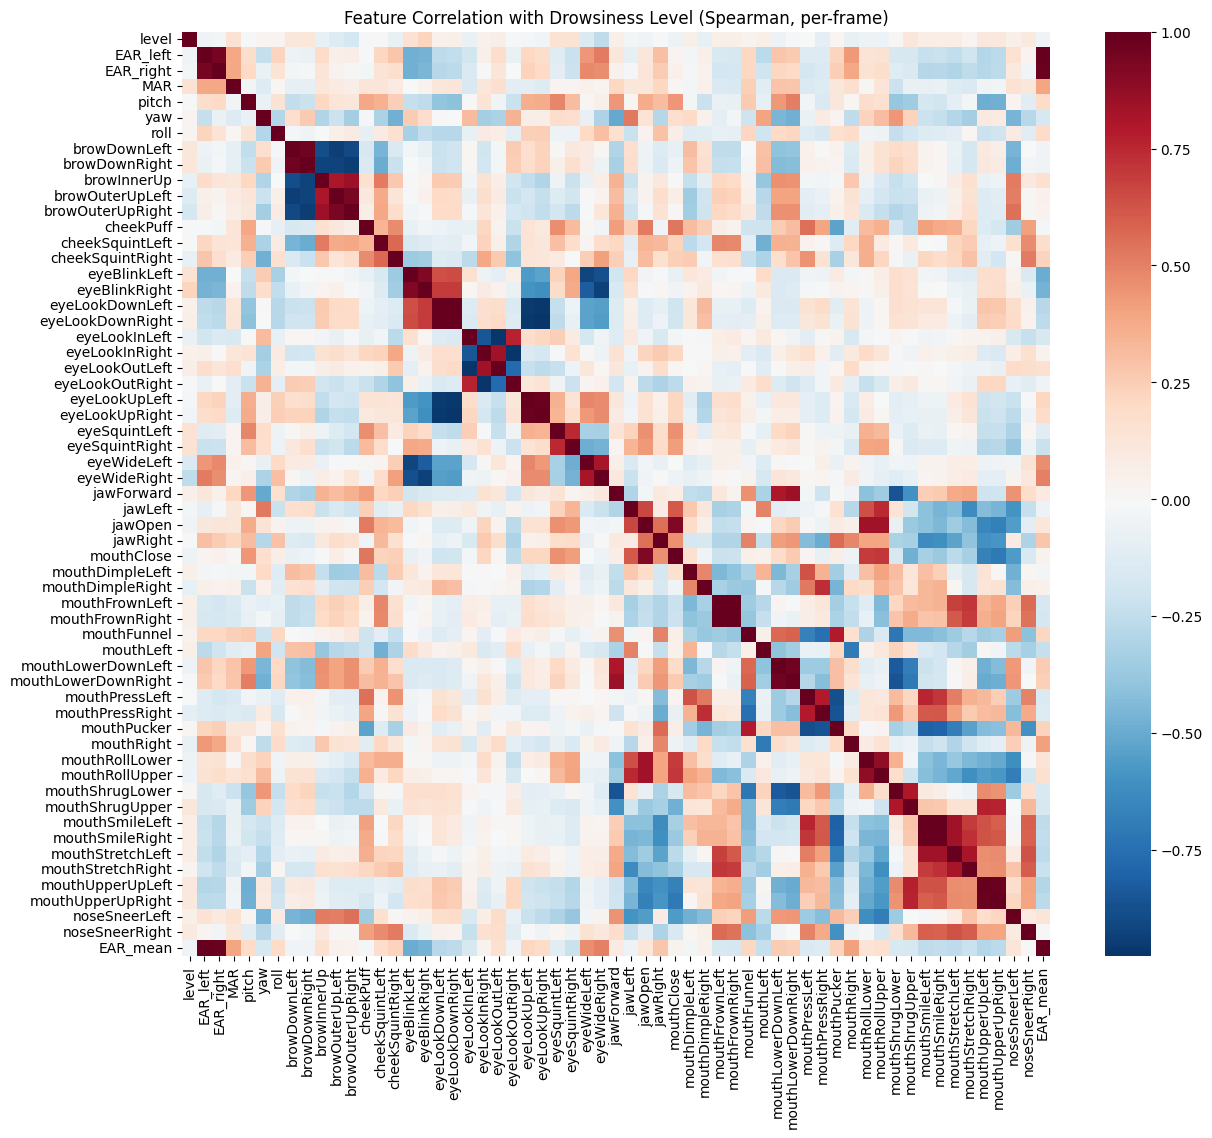

Interpretation: Look for features with high absolute correlation with 'level'.
Negative correlation with EAR is expected (eyes close as level increases).


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Correlate numeric feature columns against 'level'; drop identifier/constant columns.
id_cols = ['subject', 'parent_video', 'frame_idx', 'ear_mar_valid']
corr_cols = [c for c in df_frame_features.columns if c not in id_cols]
corr = df_frame_features[corr_cols].corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='RdBu_r', center=0, xticklabels=True, yticklabels=True)
plt.title("Feature Correlation with Drowsiness Level (Spearman, per-frame)")
plt.show()

print("Interpretation: Look for features with high absolute correlation with 'level'.")
print("Negative correlation with EAR is expected (eyes close as level increases).")


### Statistical Significance (Kruskal-Wallis)


We check whether the distribution of key features significantly differs across the 3 drowsiness levels.


Kruskal-Wallis H-test for EAR_mean across levels:
H-statistic: 1578.0114
p-value: 0.0000e+00

✅ SUCCESS: EAR_mean is statistically different across drowsiness levels.


/tmp/ipykernel_985/1395628696.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='EAR_mean', data=df_frame_features, palette='Blues')


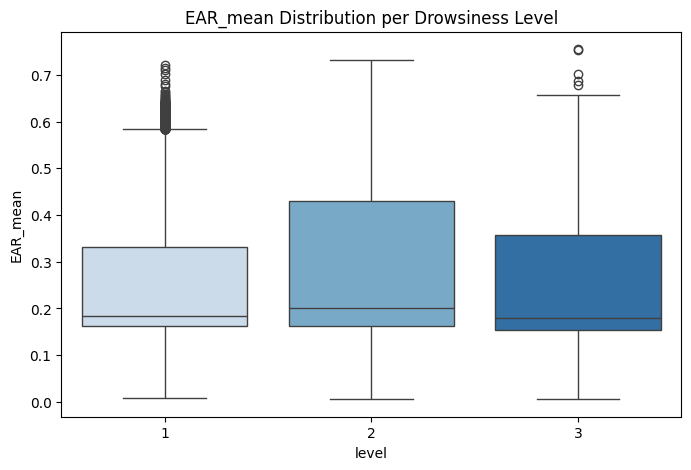

In [29]:
# Group 'EAR_mean' by level
groups = [df_frame_features[df_frame_features['level'] == i]['EAR_mean'] for i in range(1, 4)]  # 1=Alert, 2=Low Vigilant, 3=Drowsy
groups = [g for g in groups if len(g) > 0]

H_stat, p_val = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for EAR_mean across levels:")
print(f"H-statistic: {H_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ SUCCESS: EAR_mean is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='EAR_mean', data=df_frame_features, palette='Blues')
plt.title("EAR_mean Distribution per Drowsiness Level")
plt.show()


Kruskal-Wallis H-test for MAR across levels:
H-statistic: 6977.3066
p-value: 0.0000e+00

✅ SUCCESS: MAR is statistically different across drowsiness levels.


/tmp/ipykernel_985/3606452277.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='MAR', data=df_frame_features, palette='Oranges')


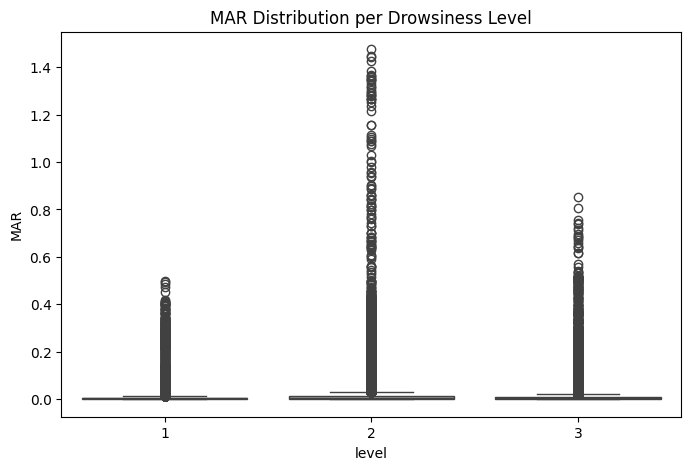

In [30]:
# Group 'MAR' by level
groups = [df_frame_features[df_frame_features['level'] == i]['MAR'] for i in range(1, 4)]  # 1=Alert, 2=Low Vigilant, 3=Drowsy
groups = [g for g in groups if len(g) > 0]

H_stat, p_val = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for MAR across levels:")
print(f"H-statistic: {H_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ SUCCESS: MAR is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='MAR', data=df_frame_features, palette='Oranges')
plt.title("MAR Distribution per Drowsiness Level")
plt.show()


Kruskal-Wallis H-test for eyeBlinkRight across levels:
H-statistic: 10930.3245
p-value: 0.0000e+00

✅ SUCCESS: eyeBlinkRight is statistically different across drowsiness levels.


/tmp/ipykernel_985/4214374757.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='eyeBlinkRight', data=df_frame_features, palette='Greens')


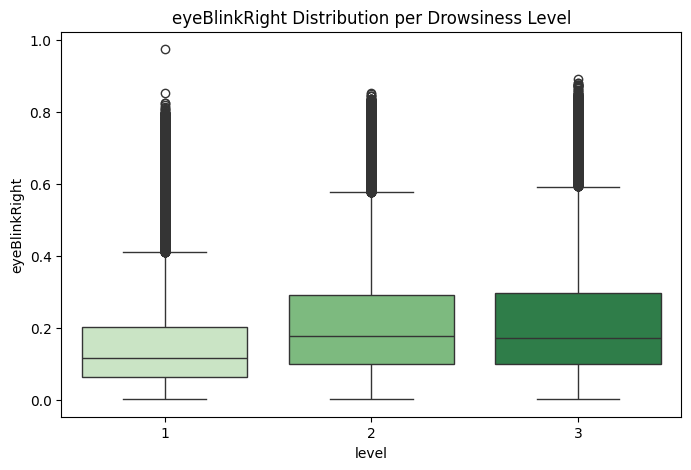

In [31]:
# Group 'eyeBlinkRight' by level
groups = [df_frame_features[df_frame_features['level'] == i]['eyeBlinkRight'] for i in range(1, 4)]  # 1=Alert, 2=Low Vigilant, 3=Drowsy
groups = [g for g in groups if len(g) > 0]

H_stat, p_val = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for eyeBlinkRight across levels:")
print(f"H-statistic: {H_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ SUCCESS: eyeBlinkRight is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='eyeBlinkRight', data=df_frame_features, palette='Greens')
plt.title("eyeBlinkRight Distribution per Drowsiness Level")
plt.show()


Kruskal-Wallis H-test for mouthFunnel across levels:
H-statistic: 1557.1070
p-value: 0.0000e+00

✅ SUCCESS: mouthFunnel is statistically different across drowsiness levels.


/tmp/ipykernel_985/1038424891.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='mouthFunnel', data=df_frame_features, palette='Purples')


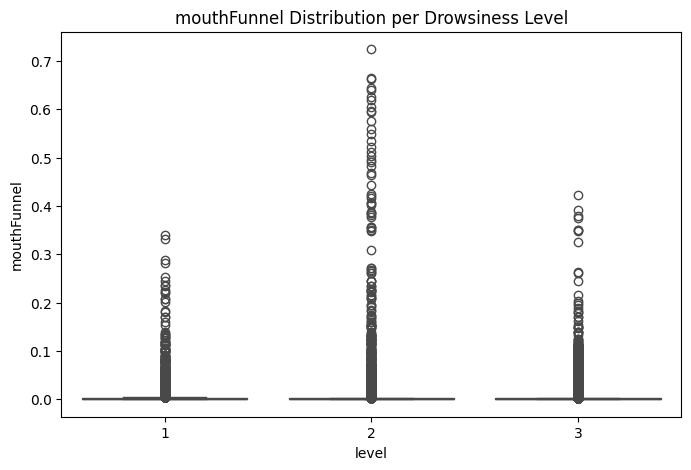

In [32]:
# Group 'mouthFunnel' by level
groups = [df_frame_features[df_frame_features['level'] == i]['mouthFunnel'] for i in range(1, 4)]  # 1=Alert, 2=Low Vigilant, 3=Drowsy
groups = [g for g in groups if len(g) > 0]

H_stat, p_val = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for mouthFunnel across levels:")
print(f"H-statistic: {H_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ SUCCESS: mouthFunnel is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='mouthFunnel', data=df_frame_features, palette='Purples')
plt.title("mouthFunnel Distribution per Drowsiness Level")
plt.show()


## Comprehensive Feature Correlation with Drowsiness Level


To decide which features to feed the RandomForest and Dense NN, we rank every feature by its
absolute Spearman correlation with `level`.


In [33]:
correlation_with_level = df_frame_features[corr_cols].corr(method='spearman')['level'].drop('level')
correlation_with_level = correlation_with_level.reindex(correlation_with_level.abs().sort_values(ascending=False).index)

print("Spearman Correlation with Drowsiness Level (sorted by absolute value):")
print(correlation_with_level)


Spearman Correlation with Drowsiness Level (sorted by absolute value):
eyeWideRight          -0.257756
eyeBlinkRight          0.225286
browOuterUpRight      -0.176188
MAR                    0.158470
eyeBlinkLeft           0.158035
eyeSquintLeft          0.156450
eyeWideLeft           -0.154756
eyeSquintRight         0.149502
browOuterUpLeft       -0.129856
browDownRight          0.125997
mouthShrugUpper        0.119576
browDownLeft           0.113188
mouthUpperUpLeft       0.111782
mouthUpperUpRight      0.109318
noseSneerRight         0.104053
mouthPressRight       -0.102089
browInnerUp           -0.084535
mouthDimpleRight      -0.083586
mouthSmileLeft         0.081317
mouthStretchLeft       0.079957
cheekSquintRight      -0.078714
mouthRight            -0.077965
mouthSmileRight        0.073951
eyeLookInLeft         -0.071477
eyeLookOutLeft         0.066323
mouthDimpleLeft        0.065784
mouthRollUpper        -0.063229
mouthLowerDownLeft    -0.062578
eyeLookDownRight       0.057770
m

### Reading these results

The same features that were expected to matter under window-mean aggregation
(`EAR_mean`, `eyeBlinkLeft/Right`, `eyeSquintLeft/Right`, `jawOpen`, `Pitch`) should still show up
here, since a per-frame value is just an unaggregated version of the same signal. Two things are
worth calling out explicitly for the titulación report:

* Per-frame correlations are typically **noisier** (lower magnitude) than the window-mean
  correlations reported by the original `02_model_training.ipynb`, because averaging over a
  window smooths out frame-level jitter (blink transients, brief tracking noise) that a single
  frame doesn't get to average away. Don't be surprised if the same feature's correlation looks
  weaker here than it did in the old windowed analysis — it's the same underlying relationship,
  observed at finer granularity.
* `MAR` and `mouthFunnel` were expected to track yawning but come out weakly correlated even here
  — consistent with the earlier finding that yawning is a *dynamic* (multi-frame) event a static
  ratio doesn't capture well. This is worth stating plainly as a known limitation of the flat,
  single-frame feature set (and, by extension, of the RandomForest, Dense NN, and CNN models
  trained on it) rather than something a threshold tweak will fix.

`04_random_forest_training.ipynb` and `05_dense_nn_training.ipynb` both select their input
features from this ranking.


# Temporal Feature Enrichment (Rolling Features)

The Spearman correlation analysis above measured the ceiling of this dataset plainly: the best
single per-frame feature (`eyeWideRight`) only reaches |r| = 0.26, and `EAR_mean` — the feature
this whole geometric pipeline was designed around — sits at essentially zero (-0.04). That's not
a modeling problem; it's that a single frame's *instantaneous* eye-openness value can't carry the
signal that actually indicates drowsiness: **how long or how fast the eyes have been closing**,
which is a property of a sequence, not a snapshot.

This section recovers a slice of that temporal signal **without touching video or MediaPipe
again** — every frame's full sequence within its clip is already sitting in `frame_features.csv`,
ordered by `frame_idx`, just currently discarded row-by-row. We compute **causal (backward-looking
only) rolling statistics** — trailing mean/std over a short and a longer window, plus
frame-to-frame rate of change — grouped by `(subject, parent_video)` so a rolling window never
crosses a clip boundary.

**Why backward-looking only, strictly.** This has to mirror how the real system would compute it
live: at inference time only *past* frames exist, never future ones. A rolling window that also
looked forward would leak information a deployed model could never actually have — the same
causality constraint the LSTM's `feature_buffer` already respects (oldest frame dropped, newest
appended at the end, never the reverse).

Output: `dataset_processed/frame_features_enriched.csv` — the original `frame_features.csv` is
left untouched (still there for direct before/after comparison), this is a new, separate file
with additional rolling-feature columns.


In [34]:
import pandas as pd
import numpy as np

df_frame_features = pd.read_csv(frame_features_csv_path)
df_frame_features['EAR_mean'] = (df_frame_features['EAR_left'] + df_frame_features['EAR_right']) / 2

# Sort so each clip's frames are contiguous and in temporal order -- required for rolling/diff
# to mean anything, and for the groupby-rolling alignment below to be correct.
df_frame_features = df_frame_features.sort_values(['subject', 'parent_video', 'frame_idx']).reset_index(drop=True)

print(f"Loaded {len(df_frame_features)} frame rows for enrichment.")


Loaded 173730 frame rows for enrichment.


### Rolling Window Configuration

Two window lengths: a **short** one (1s @ 10 FPS = 10 frames) to capture fast transients like an
individual blink, and a **longer** one (3s = 30 frames) to capture a slower trend (sustained
partial eye closure). Base columns are the 7 geometric ratios plus the blendshapes the Spearman
ranking flagged as most correlated with level — rolling every one of the 58 columns would triple
the feature count for little benefit, since the weakest-correlated raw features are unlikely to
suddenly become informative just because they're smoothed.


In [35]:
ROLL_WINDOW_SHORT = 10   # 1.0s @ 10 FPS
ROLL_WINDOW_LONG = 30    # 3.0s @ 10 FPS

rolling_base_cols = [
    'EAR_mean', 'EAR_left', 'EAR_right', 'MAR', 'pitch', 'yaw', 'roll',
    'eyeWideRight', 'eyeWideLeft', 'eyeBlinkRight', 'eyeBlinkLeft',
    'eyeSquintLeft', 'eyeSquintRight', 'browOuterUpRight', 'browOuterUpLeft',
    'browDownRight', 'browDownLeft', 'mouthShrugUpper', 'jawOpen',
]

print(f"Rolling base columns ({len(rolling_base_cols)}): {rolling_base_cols}")
print(f"Windows: short={ROLL_WINDOW_SHORT} frames, long={ROLL_WINDOW_LONG} frames")


Rolling base columns (19): ['EAR_mean', 'EAR_left', 'EAR_right', 'MAR', 'pitch', 'yaw', 'roll', 'eyeWideRight', 'eyeWideLeft', 'eyeBlinkRight', 'eyeBlinkLeft', 'eyeSquintLeft', 'eyeSquintRight', 'browOuterUpRight', 'browOuterUpLeft', 'browDownRight', 'browDownLeft', 'mouthShrugUpper', 'jawOpen']
Windows: short=10 frames, long=30 frames


### Computing Rolling Mean / Std / Rate-of-Change

`min_periods=1` so the first few frames of a clip (before a full window is available) still get a value, computed from however many real past frames exist so far -- exactly like the LSTM's zero-padded buffer represents "not enough history yet" during warm-up, except here it's a genuine partial-window statistic rather than padding.


In [36]:
def add_rolling_features(df, group_cols, feature_cols, window, stat):
    """Causal (backward-only) rolling stat per group, aligned back to df's original row order."""
    g = df.groupby(group_cols, sort=False)[feature_cols]
    if stat == 'mean':
        result = g.rolling(window=window, min_periods=1).mean()
    elif stat == 'std':
        result = g.rolling(window=window, min_periods=1).std()
    else:
        raise ValueError(f"Unknown stat: {stat}")
    # groupby().rolling() returns a MultiIndex of (group_cols..., original_index) -- drop the
    # group levels and restore original row order so this aligns 1:1 with df.
    result = result.reset_index(level=list(range(len(group_cols))), drop=True).sort_index()
    return result

df_enriched = df_frame_features.copy()
group_cols = ['subject', 'parent_video']

for window, tag in [(ROLL_WINDOW_SHORT, f'{ROLL_WINDOW_SHORT}f'), (ROLL_WINDOW_LONG, f'{ROLL_WINDOW_LONG}f')]:
    roll_mean = add_rolling_features(df_frame_features, group_cols, rolling_base_cols, window, 'mean')
    roll_mean.columns = [f'{c}_rollmean_{tag}' for c in rolling_base_cols]

    roll_std = add_rolling_features(df_frame_features, group_cols, rolling_base_cols, window, 'std').fillna(0.0)
    roll_std.columns = [f'{c}_rollstd_{tag}' for c in rolling_base_cols]

    df_enriched = pd.concat([df_enriched, roll_mean, roll_std], axis=1)

# Frame-to-frame rate of change (first derivative) -- the first frame of each clip has no prior
# frame, so its delta is undefined and filled with 0.0 (no change from a nonexistent past frame).
delta = df_frame_features.groupby(group_cols, sort=False)[rolling_base_cols].diff().fillna(0.0)
delta.columns = [f'{c}_delta1' for c in rolling_base_cols]
df_enriched = pd.concat([df_enriched, delta], axis=1)

print(f"Enriched dataset shape: {df_enriched.shape} (was {df_frame_features.shape})")
print(f"New columns added: {df_enriched.shape[1] - df_frame_features.shape[1]}")


Enriched dataset shape: (173730, 158) (was (173730, 63))
New columns added: 95


### Sanity Check: Did Enrichment Actually Help?

Before anyone trains on this, verify the rolling features actually correlate more strongly with `level` than the raw single-frame values they're derived from -- if they don't, the enrichment isn't earning its added complexity.


In [37]:
from scipy import stats

comparison_rows = []
for base_col in ['EAR_mean', 'MAR', 'eyeBlinkRight']:
    raw_corr = df_enriched[[base_col, 'level']].corr(method='spearman').iloc[0, 1]
    for suffix in [f'_rollmean_{ROLL_WINDOW_SHORT}f', f'_rollmean_{ROLL_WINDOW_LONG}f',
                   f'_rollstd_{ROLL_WINDOW_SHORT}f', f'_rollstd_{ROLL_WINDOW_LONG}f', '_delta1']:
        col = f'{base_col}{suffix}'
        enriched_corr = df_enriched[[col, 'level']].corr(method='spearman').iloc[0, 1]
        comparison_rows.append({'base_feature': base_col, 'variant': suffix.strip('_'),
                                 'raw_|r|': abs(raw_corr), 'enriched_|r|': abs(enriched_corr)})

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

if (comparison_df['enriched_|r|'] > comparison_df['raw_|r|']).mean() > 0.5:
    print("\n✅ Most rolling variants beat their raw counterpart's correlation -- enrichment is adding real signal.")
else:
    print("\n⚠️  Rolling variants aren't clearly beating raw correlations -- worth double-checking the "
          "window sizes / grouping before training on this.")


 base_feature      variant  raw_|r|  enriched_|r|
     EAR_mean rollmean_10f 0.042641      0.049493
     EAR_mean rollmean_30f 0.042641      0.057624
     EAR_mean  rollstd_10f 0.042641      0.066248
     EAR_mean  rollstd_30f 0.042641      0.121772
     EAR_mean       delta1 0.042641      0.000309
          MAR rollmean_10f 0.158470      0.159686
          MAR rollmean_30f 0.158470      0.159351
          MAR  rollstd_10f 0.158470      0.059222
          MAR  rollstd_30f 0.158470      0.055462
          MAR       delta1 0.158470      0.004402
eyeBlinkRight rollmean_10f 0.225286      0.242930
eyeBlinkRight rollmean_30f 0.225286      0.267261
eyeBlinkRight  rollstd_10f 0.225286      0.080294
eyeBlinkRight  rollstd_30f 0.225286      0.130647
eyeBlinkRight       delta1 0.225286      0.003762

✅ Most rolling variants beat their raw counterpart's correlation -- enrichment is adding real signal.


### Writing the Enriched CSV


In [38]:
enriched_csv_path = os.path.join(processed_folder, "frame_features_enriched.csv")
df_enriched.to_csv(enriched_csv_path, index=False)
print(f"✅ Enriched dataset written: {enriched_csv_path}")
print(f"   Shape: {df_enriched.shape}")


✅ Enriched dataset written: /content/drive/MyDrive/Argus/dataset/dataset_processed/frame_features_enriched.csv
   Shape: (173730, 158)
